Predicting Electric Vehicle Transition and Forecasting Monthly Energy Consumption and Charging Costs

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer 
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv("EV.csv")

In [4]:
df.head(10)

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9
5,23,19315.0,Bachelor,Urban,32.8,167.6,SUV,4.0,275.7,8.0,...,4.3,6.7,4.0,8.5,5.0,4.9,0,Low,118.1,14.1
6,53,52110.0,High School,Suburban,14.0,99.0,Hatchback,2.7,90.1,6.8,...,6.5,5.7,5.6,4.4,6.2,7.3,0,Medium,90.9,9.6
7,69,126618.0,High School,Urban,40.9,314.9,Truck,1.7,391.6,9.6,...,6.9,7.2,7.5,5.9,7.4,7.4,0,High,203.3,65.0
8,53,62712.0,Bachelor,Urban,42.1,256.8,Hatchback,3.1,397.9,8.3,...,6.6,6.6,4.7,6.8,5.1,6.6,0,Medium,193.3,28.5
9,69,41775.0,High School,Rural,40.9,262.3,Sedan,7.0,363.9,4.7,...,4.9,4.1,5.5,6.3,3.8,5.1,0,Low,202.4,47.5


In [5]:
df.columns

Index(['age', 'annual_income', 'education_level', 'city_type',
       'daily_commute_km', 'weekly_travel_distance_km', 'current_vehicle_type',
       'vehicle_age_years', 'fuel_expense_per_month',
       'charging_station_accessibility', 'nearest_charging_station_km',
       'home_charging_available', 'electricity_cost_per_kwh',
       'environmental_awareness_score', 'government_incentive_awareness',
       'technology_affinity_score', 'range_anxiety_score',
       'battery_replacement_concern', 'ev_knowledge_score',
       'previous_ev_experience', 'ev_adoption_likelihood',
       'monthly_energy_consumption_kwh', 'monthly_charging_cost'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  float64
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

In [7]:
df.describe()

,age,annual_income,daily_commute_km,weekly_travel_distance_km,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,nearest_charging_station_km,home_charging_available,electricity_cost_per_kwh,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,monthly_energy_consumption_kwh,monthly_charging_cost
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49500.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49500.000000,50000.000000,50000.000000,50000.000000
mean,44.996080,44311.869380,35.169358,228.727200,6.012842,295.169608,5.892947,7.132370,0.64976,0.215359,6.831854,5.979970,6.721914,5.288046,4.998338,6.755673,0.198200,186.740260,40.235028
std,14.110844,26109.170784,14.736042,101.147254,2.947132,130.178552,2.152186,4.801992,0.47705,0.077914,1.920217,1.955106,1.990730,2.059862,1.955411,1.945842,0.398648,88.245302,24.940343
min,21.000000,5104.000000,5.000000,25.000000,0.000000,-99.700000,1.000000,0.500000,0.00000,0.080000,2.000000,1.000000,2.000000,2.000000,1.000000,1.000000,0.000000,15.600000,1.400000
25%,33.000000,25617.750000,25.000000,157.700000,3.900000,205.200000,4.400000,3.000000,0.00000,0.150000,5.400000,4.600000,5.200000,3.700000,3.600000,5.300000,0.000000,124.500000,21.600000
50%,45.000000,37891.000000,35.100000,224.100000,6.000000,294.800000,5.900000,6.900000,1.00000,0.220000,7.000000,6.000000,6.700000,5.000000,5.000000,7.000000,0.000000,179.300000,35.200000
75%,57.000000,56051.250000,45.200000,294.500000,8.000000,383.000000,7.400000,10.700000,1.00000,0.280000,8.400000,7.300000,8.500000,6.800000,6.300000,8.300000,0.000000,241.500000,54.100000
max,69.000000,250000.000000,97.900000,732.300000,20.000000,862.000000,10.000000,28.500000,1.00000,0.350000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,1.000000,645.900000,199.600000


Dataset terdiri dari 50.000 Obeservasi dengan rata-rata umur partisipan 45 tahun dengan usia minimal 21 tahun dan usia maksimal 69 tahun. Rata-rata penghasilan berada diangka 44.511,8 USD per tahun dengan rata-rata jarak tempuh per minggu sekitar 228,7 KM atau sekitar 35,16 KM per hari. Rata-rata umur kendaraan partisipan adalah 6 tahun dengan pengeluaran rata-rata untk bahan bakar per bulan sekitar 295,16 USD.

In [8]:
print(f"Jumlah Kolom {df.shape[0]} dan baris {df.shape[1]}")

Jumlah Kolom 50000 dan baris 23


In [9]:
num_cols = df.select_dtypes(include="number").columns
cat_cols = df.select_dtypes(include="object").columns

In [10]:
print(f"Jumlah Num Cols:{len(num_cols)}")

Jumlah Num Cols:19


In [11]:
print(f"Jumlah Cat Cols:{len(cat_cols)}")

Jumlah Cat Cols:4


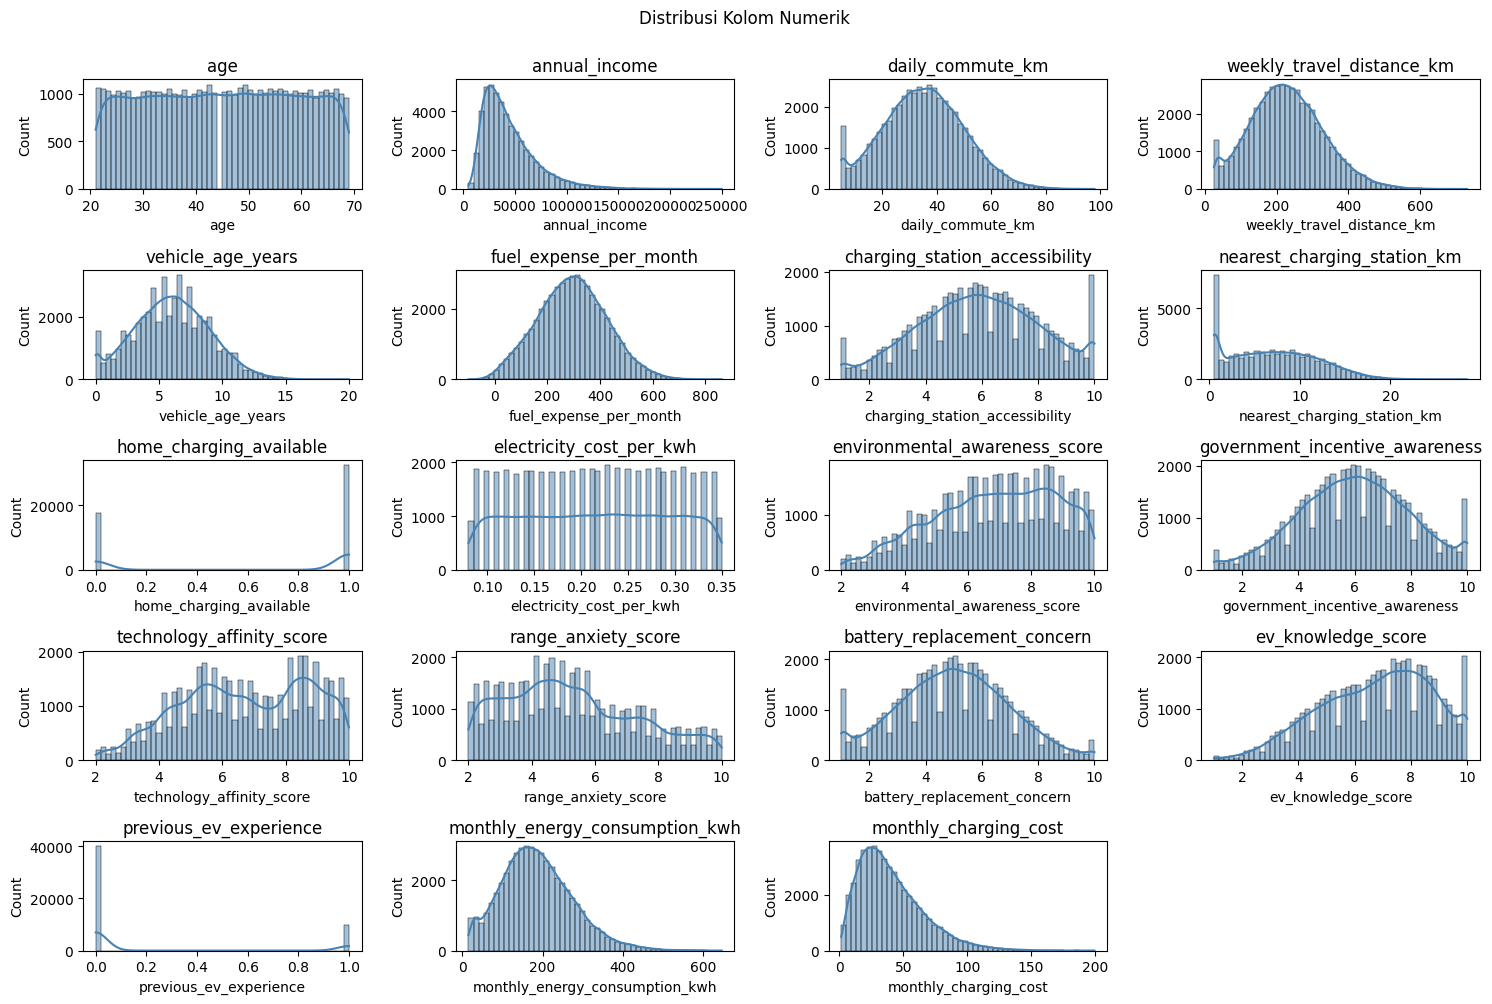

In [12]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(5,4,i)
    sns.histplot(df[col], bins=50, kde=True, color="steelblue")
    plt.title(col)

plt.suptitle("Distribusi Kolom Numerik", y=1)
plt.tight_layout()
plt.show()

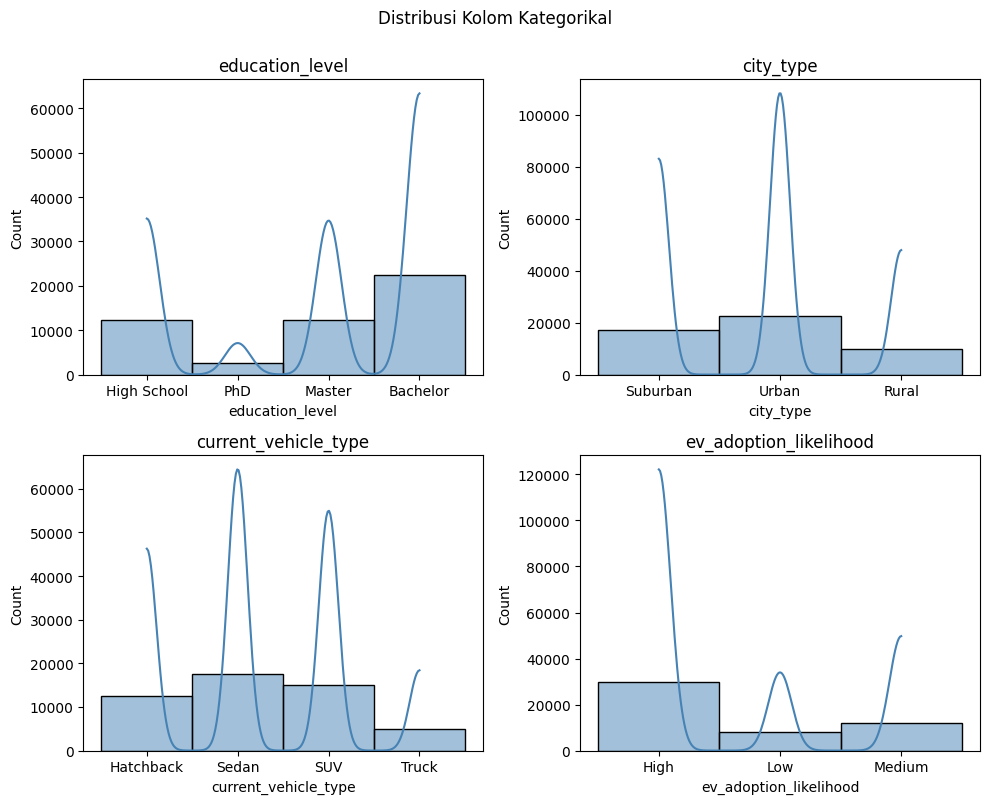

In [13]:
plt.figure(figsize=(10,8))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(2,2, i)
    sns.histplot(df[col], bins=50, kde=True, color="steelblue")
    plt.title(col)

plt.suptitle("Distribusi Kolom Kategorikal", y=1)
plt.tight_layout()
plt.show()

In [14]:
# Cek Skewness
print("Jumlah Skewness:", df[num_cols].skew())

Jumlah Skewness: age                              -0.007778
annual_income                     1.650789
daily_commute_km                  0.127231
weekly_travel_distance_km         0.317259
vehicle_age_years                 0.123382
fuel_expense_per_month            0.104406
charging_station_accessibility   -0.072112
nearest_charging_station_km       0.339479
home_charging_available          -0.627884
electricity_cost_per_kwh         -0.009990
environmental_awareness_score    -0.339405
government_incentive_awareness   -0.084159
technology_affinity_score        -0.188391
range_anxiety_score               0.426308
battery_replacement_concern       0.085100
ev_knowledge_score               -0.369222
previous_ev_experience            1.514180
monthly_energy_consumption_kwh    0.538773
monthly_charging_cost             1.067244
dtype: float64


In [16]:
df['annual_income'] = np.log1p(df['annual_income'])
df['monthly_charging_cost'] = np.log1p(df['monthly_charging_cost'])
print(df[num_cols].skew())

age                              -0.007778
annual_income                     0.010502
daily_commute_km                  0.127231
weekly_travel_distance_km         0.317259
vehicle_age_years                 0.123382
fuel_expense_per_month            0.104406
charging_station_accessibility   -0.072112
nearest_charging_station_km       0.339479
home_charging_available          -0.627884
electricity_cost_per_kwh         -0.009990
environmental_awareness_score    -0.339405
government_incentive_awareness   -0.084159
technology_affinity_score        -0.188391
range_anxiety_score               0.426308
battery_replacement_concern       0.085100
ev_knowledge_score               -0.369222
previous_ev_experience            1.514180
monthly_energy_consumption_kwh    0.538773
monthly_charging_cost            -0.600963
dtype: float64
